# k-nearest neighbours, and where distance stops working

Every model so far has **learned a rule**: coefficients, a boundary, a threshold.
This notebook starts with a method that learns nothing at all. It stores the
training set, and when asked about a new point it looks up the nearest ones and
takes a vote.

That sounds too simple to work, and on the right problem it beats everything in
lessons 3 and 4 without a single parameter being fitted.

Then it falls apart, and the way it falls apart is the most important idea in
this lesson.

By the end you will have:

1. implemented k-nearest neighbours in about eight lines, because it is one of
   the few algorithms where writing it is quicker than reading about it,
2. seen it solve a problem on which **logistic regression scores exactly the
   base rate** — it learns nothing whatsoever,
3. watched its accuracy collapse as columns containing *nothing* are added,
4. and measured why: in high dimensions, the nearest point stops being near.

The data is 1,200 industrial pumps. Each has a design operating envelope, and a
pump is faulty when its readings fall outside it — **too low or too high**. That
one physical fact is what makes the problem interesting.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from pump_data import load_pumps, load_with_noise

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

X, y = load_pumps()
print(f"{len(X)} pumps, {int(y.sum())} faulty ({y.mean():.1%})")
X.head()

1200 pumps, 735 faulty (61.3%)


,vibration_hz,pressure_bar
0,35.561,5.2330
1,38.209,5.4385
2,45.701,4.7153
3,40.442,4.8090
4,42.845,5.6183


## 1. Look at it first

Lesson 2's rule. Two columns, so the whole problem fits in one picture — which
will not be true again after this lesson.

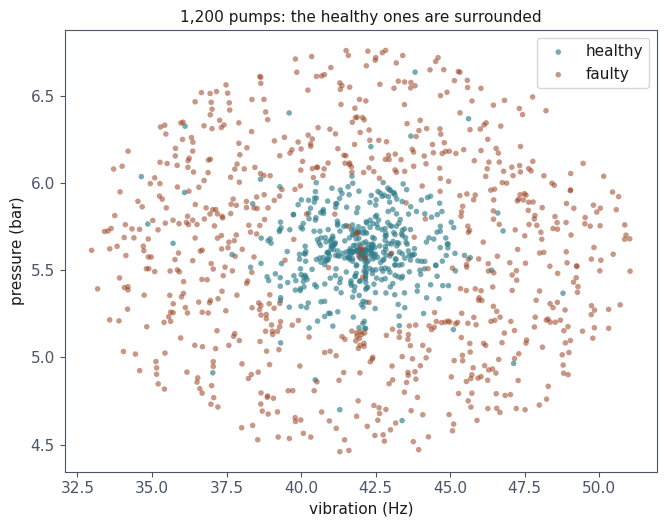

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 5.4))
healthy, faulty = y == 0, y == 1
ax.scatter(X.loc[healthy, "vibration_hz"], X.loc[healthy, "pressure_bar"],
           s=16, color=TEAL, alpha=.65, label="healthy", edgecolor="none")
ax.scatter(X.loc[faulty, "vibration_hz"], X.loc[faulty, "pressure_bar"],
           s=16, color=RUST, alpha=.55, label="faulty", edgecolor="none")
ax.set_xlabel("vibration (Hz)"); ax.set_ylabel("pressure (bar)")
ax.set_title("1,200 pumps: the healthy ones are surrounded", fontsize=11)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "pump_scatter.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

**No straight line separates these classes.** The healthy pumps form a blob in
the middle and the faulty ones surround it, because a pump can fail by running
too slow *or* too fast.

Every model in lessons 3 and 4 draws a straight boundary. Let us confirm what
that costs before building anything new.

In [3]:
baseline = max(y.mean(), 1 - y.mean())
logistic = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000)),
    X, y, cv=folds, scoring="accuracy")

print(f"always predict the majority class : {baseline:.3f}")
print(f"logistic regression (lesson 4)    : {logistic.mean():.3f} "
      f"+/- {logistic.std():.3f}")

always predict the majority class : 0.613
logistic regression (lesson 4)    : 0.613 +/- 0.000


**0.613 against a baseline of 0.613.** Logistic regression has not been
slightly beaten here — it has learned *nothing at all*. It predicts "faulty" for
every pump, because with a straight boundary that is genuinely the best it can
do.

Lesson 5's habit applies: notice that the standard deviation across folds is
zero. A model that gives the same answer to everything is very consistent.

## 2. k-nearest neighbours, written out

The whole algorithm:

> To classify a new point, find the $k$ training points closest to it and take
> the majority vote.

There is no training. Fitting means *storing the data*, which is why k-NN is
sometimes called a lazy learner — an unusually honest name for an algorithm.

Two decisions are hidden in that sentence, and both matter:

**What "closest" means.** Almost always Euclidean distance, which is why the
features must be on comparable scales. Vibration ranges over tens of Hz and
pressure over a couple of bar; without scaling, vibration would decide every
neighbour by itself. This is lesson 2's scaling argument arriving with real
consequences.

**What $k$ is.** Section 3.

In [4]:
def knn_predict(X_train, y_train, X_query, k=5):
    """Classify each query point by a majority vote of its k nearest neighbours."""
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train)
    predictions = []
    for point in np.asarray(X_query, dtype=float):
        distance = np.sqrt(((X_train - point) ** 2).sum(axis=1))
        nearest = np.argsort(distance)[:k]
        predictions.append(np.bincount(y_train[nearest]).argmax())
    return np.array(predictions)


# Scale first, then split by hand so the comparison is like for like.
scaler = StandardScaler().fit(X)
Z = scaler.transform(X)
rng = np.random.default_rng(0)
test_index = rng.choice(len(Z), 300, replace=False)
train_index = np.setdiff1d(np.arange(len(Z)), test_index)

ours = knn_predict(Z[train_index], y.to_numpy()[train_index], Z[test_index], k=5)
theirs = (KNeighborsClassifier(5)
          .fit(Z[train_index], y.to_numpy()[train_index])
          .predict(Z[test_index]))

print(f"our eight lines agree with scikit-learn on "
      f"{(ours == theirs).mean():.1%} of the test points")
print(f"accuracy: {(ours == y.to_numpy()[test_index]).mean():.3f}")

our eight lines agree with scikit-learn on 100.0% of the test points
accuracy: 0.937


## 3. Choosing k

$k$ controls the same trade-off lesson 5 decomposed, in a form you can see
directly.

**Small $k$** — the boundary follows every point, including the mislabelled
ones. Low bias, high variance. At $k = 1$ the training accuracy is a perfect
1.000, and it means nothing: every point is its own nearest neighbour.

**Large $k$** — the vote is taken over a wide neighbourhood, so the boundary
smooths out and eventually ignores real structure. High bias, low variance. In
the limit $k = m$ every point gets the same answer and we are back at the
majority-class baseline; well before that, the boundary is already too coarse to
follow anything.

Note that this data has **4% of its labels deliberately flipped**, so no model
can exceed about 0.96. That ceiling is the noise floor of lesson 5, arriving in
a classification problem.

In [5]:
ks = [1, 3, 5, 9, 15, 25, 51, 101, 201, 401]
rows = []
for k in ks:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(k))
    scores = cross_val_score(model, X, y, cv=folds, scoring="accuracy")
    fitted = model.fit(X, y)
    rows.append({"k": k,
                 "training": fitted.score(X, y),
                 "cross-validated": scores.mean(),
                 "std": scores.std()})

sweep = pd.DataFrame(rows).set_index("k")
print(sweep.to_string(float_format=lambda v: f"{v:.3f}"))
best = int(sweep["cross-validated"].idxmax())
print(f"\nbest k: {best}  ({sweep.loc[best, 'cross-validated']:.3f})")
print(f"noise ceiling: about 0.96")

     training  cross-validated   std
k                                   
1       1.000            0.912 0.013
3       0.957            0.941 0.005
5       0.953            0.944 0.006
9       0.953            0.943 0.005
15      0.948            0.938 0.005
25      0.943            0.938 0.003
51      0.940            0.933 0.006
101     0.934            0.925 0.005
201     0.899            0.881 0.012
401     0.828            0.708 0.018

best k: 5  (0.944)
noise ceiling: about 0.96


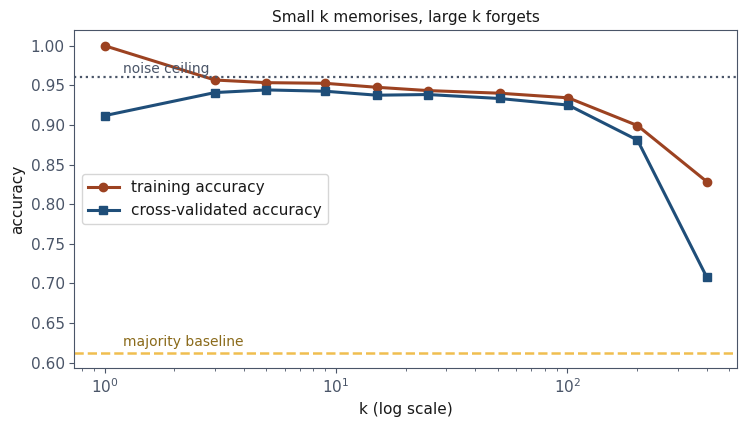

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(sweep.index, sweep["training"], "o-", color=RUST, lw=2.2,
        label="training accuracy")
ax.plot(sweep.index, sweep["cross-validated"], "s-", color=BLUE, lw=2.2,
        label="cross-validated accuracy")
ax.axhline(0.96, color=SLATE, ls=":", lw=1.6)
ax.text(1.2, 0.965, "noise ceiling", color=SLATE, fontsize=10)
ax.axhline(max(y.mean(), 1 - y.mean()), color=GOLD, ls="--", lw=1.8)
ax.text(1.2, max(y.mean(), 1 - y.mean()) + 0.008, "majority baseline",
        color="#8a6a1a", fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("k (log scale)"); ax.set_ylabel("accuracy")
ax.set_title("Small k memorises, large k forgets", fontsize=11)
ax.legend(loc="center left")
fig.tight_layout()
fig.savefig(FIGURES / "knn_choosing_k.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Read the red curve at $k = 1$: **training accuracy 1.000**, and the
cross-validated accuracy well below it. That is the clearest example of the
lesson-5 point that a training score measures nothing — here it is exactly 1 by
construction, whatever the data.

The two curves converge as $k$ grows, and then both fall towards the majority
baseline together. The best value sits where the neighbourhood is wide enough to
average out the flipped labels and narrow enough to still follow the ring.

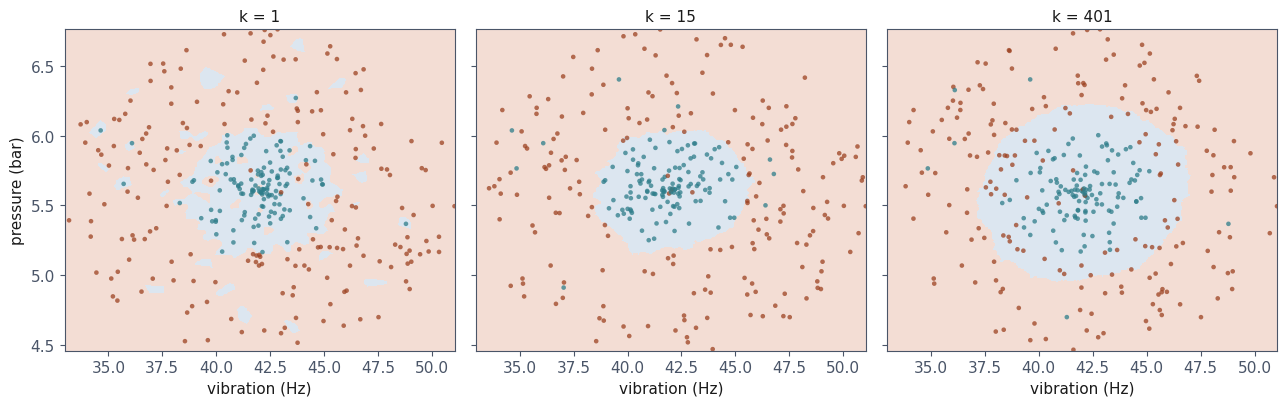

In [7]:
grid_v = np.linspace(X["vibration_hz"].min(), X["vibration_hz"].max(), 260)
grid_p = np.linspace(X["pressure_bar"].min(), X["pressure_bar"].max(), 260)
vv, pp = np.meshgrid(grid_v, grid_p)
grid = pd.DataFrame({"vibration_hz": vv.ravel(), "pressure_bar": pp.ravel()})

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, k in zip(axes, (1, 15, 401)):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(k)).fit(X, y)
    zone = model.predict(grid).reshape(vv.shape)
    ax.contourf(vv, pp, zone, levels=[-0.5, 0.5, 1.5],
                colors=["#DCE6F0", "#F3DDD4"])
    sample = rng.choice(len(X), 320, replace=False)
    ax.scatter(X.iloc[sample]["vibration_hz"], X.iloc[sample]["pressure_bar"],
               c=[TEAL if v == 0 else RUST for v in y.iloc[sample]],
               s=11, alpha=.75, edgecolor="none")
    ax.set_title(f"k = {k}", fontsize=11)
    ax.set_xlabel("vibration (Hz)")
axes[0].set_ylabel("pressure (bar)")
fig.tight_layout()
fig.savefig(FIGURES / "knn_boundaries.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Three boundaries from one dataset. At $k = 1$ the boundary is ragged and has
islands around individual mislabelled points. At $k = 15$ it is a clean disc,
close to the envelope that generated the data.

At $k = 401$ it has **inflated**: the healthy region now extends well past the
true envelope and absorbs faulty pumps, because a vote among four hundred
neighbours reaches far enough to be dominated by whichever class is larger
nearby. It has not collapsed to one class — it scores 0.708 — but it has stopped
following the boundary and started averaging over it.

**Nothing was fitted in any of the three.** The only thing that changed is how
many neighbours vote.

## 4. Now break it

k-NN just solved a problem that defeated logistic regression completely. Here is
the price.

We add columns of **pure noise** — numbers drawn from a normal distribution,
with no relationship to anything. The two real readings are untouched, so the
problem itself is exactly as solvable as before. Only the number of columns
changes.

In [8]:
rows = []
for n_noise in (0, 2, 5, 10, 25, 50, 100):
    Xn, yn = load_with_noise(n_noise)
    scores = cross_val_score(
        make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
        Xn, yn, cv=folds, scoring="accuracy")
    rows.append({"noise columns": n_noise, "total columns": Xn.shape[1],
                 "accuracy": scores.mean()})

curse = pd.DataFrame(rows).set_index("noise columns")
curse["above baseline"] = curse["accuracy"] - baseline
print(curse.to_string(float_format=lambda v: f"{v:.3f}"))

               total columns  accuracy  above baseline
noise columns                                         
0                          2     0.938           0.325
2                          4     0.895           0.282
5                          7     0.854           0.242
10                        12     0.762           0.149
25                        27     0.662           0.049
50                        52     0.602          -0.011
100                      102     0.578          -0.035


**The signal never left.** Those two real columns are still there, still
perfectly informative, still enough for a boundary that scores 0.94.

But ten useless columns cost it eighteen points of accuracy, and by fifty it
has fallen *below* the majority baseline — a model that ignored the data
entirely would now do better. It cannot find the signal any more, because
"nearest" has stopped meaning "similar in the ways that matter".

## 5. Why: in high dimensions, everything is far away

Here is the mechanism, and it is a fact about geometry rather than about k-NN.

Scatter points uniformly in a cube, pick one at random, and measure the distance
to its **nearest** neighbour and to its **farthest**. In two dimensions those
two numbers are very different — that is what makes "nearest" informative.

Watch what happens as the number of dimensions grows.

In [9]:
rng = np.random.default_rng(0)
rows = []
for d in (2, 3, 5, 10, 25, 50, 100, 250, 500):
    points = rng.random((1_000, d))
    ratios = []
    for query in rng.random((60, d)):
        distance = np.sqrt(((points - query) ** 2).sum(axis=1))
        ratios.append(distance.min() / distance.max())
    rows.append({"dimensions": d, "nearest / farthest": float(np.mean(ratios))})

concentration = pd.DataFrame(rows).set_index("dimensions")
print(concentration.to_string(float_format=lambda v: f"{v:.3f}"))

            nearest / farthest
dimensions                    
2                        0.016
3                        0.050
5                        0.118
10                       0.263
25                       0.467
50                       0.592
100                      0.701
250                      0.798
500                      0.855


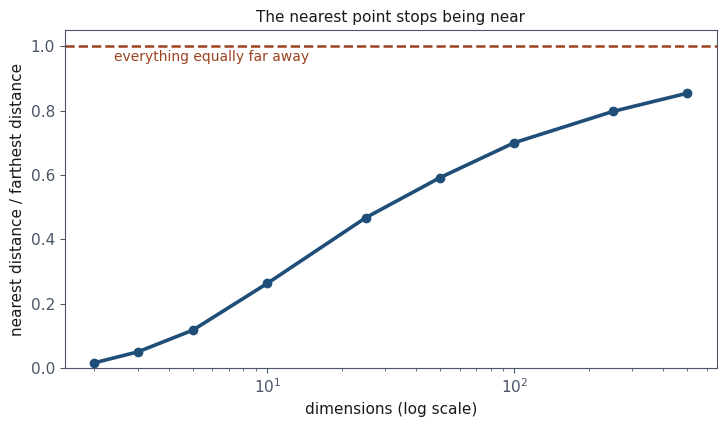

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(concentration.index, concentration["nearest / farthest"], "o-",
        color=BLUE, lw=2.6)
ax.axhline(1.0, color=RUST, ls="--", lw=1.8)
ax.text(2.4, 0.955, "everything equally far away", color=RUST, fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("dimensions (log scale)")
ax.set_ylabel("nearest distance / farthest distance")
ax.set_title("The nearest point stops being near", fontsize=11)
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(FIGURES / "distance_concentration.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

**In two dimensions the nearest point is about 2% as far away as the farthest.**
"Nearest" is a strong statement.

**In one hundred dimensions it is about 70% as far away as the farthest**, and by
five hundred it is 85%. Every point is roughly the same distance from every
other point, so the nearest one is barely nearer than a random one — and a vote
among "the nearest five" is close to a vote among five points picked at random.

That is the **curse of dimensionality**, and it is worth being precise about what
it is not. It is not that high-dimensional problems are harder to learn in
general — lesson 9's networks work in thousands of dimensions. It is that
**methods built on distance lose their footing**, because the quantity they rely
on stops varying.

**The predictable mistake here** is reasonable and common: adding features
because they might help. With a linear model an irrelevant feature costs you a
coefficient near zero and very little else. With k-NN it costs you a dimension
in the distance, and dimensions are what the method is made of.

## 6. What k-NN costs to use

No training time at all, and then you pay for it at every prediction: a naive
implementation compares the query against **every** training point, so
predicting one point costs $O(mn)$ for $m$ training rows and $n$ features.

For 1,200 pumps that is nothing. For ten million rows answering a thousand
queries a second, it is the whole engineering problem, and it is why
approximate nearest-neighbour indexes exist as an industry.

The other cost is memory: the model *is* the dataset. A model you cannot ship
without shipping your training data is a different proposition legally as well
as practically — lesson 2's Resources document is relevant here.

## What to take away

- **k-NN learns nothing and can still win.** On the pumps it scored 0.944 where
  logistic regression scored the base rate exactly, to three decimals.
- **Scale first.** Distance is meaningless across columns with different units,
  and k-NN is nothing but distance.
- **$k$ is the bias-variance dial**, and you can see it: $k=1$ memorises with a
  perfect training score, large $k$ forgets.
- **The curse of dimensionality is about distance, not difficulty.** Fifty
  columns of pure noise took k-NN below the majority baseline while the signal
  sat untouched in the first two.
- **In 100 dimensions the nearest point is 70% as far as the farthest.** That is
  the mechanism, and it is geometry rather than statistics.
- **Prediction is where the cost lands**, and the model is the dataset.

Notebook 2 takes a method that makes an assumption instead of measuring
distances — and shows it doing very well on this data, and then worse than
guessing on data one step away from it.